# 붓꽃 데이터 PCA 실습

In [47]:


from sklearn.datasets import load_iris

# np 라이브러리 불러오기
import numpy as np

#selected_eigenvectors 라이브러리 불러오기
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

데이터 형태: (150, 4)
타겟 형태: (150,)
데이터 샘플:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
타겟 샘플:
 [0 0 0 0 0]
----------------------------------------------------------------------------------
PCA 적용 전 데이터 형태: (150, 4)
특징 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
----------------------------------------------------------------------------------
공분산 행렬 형태: (4, 4)
----------------------------------------------------------------------------------
고유값 (내림차순): [4.22824171 0.24267075 0.0782095  0.02383509]
고유벡터 (내림차순):
 [[-0.36138659  0.65658877  0.58202985  0.31548719]
 [ 0.08452251  0.73016143 -0.59791083 -0.3197231 ]
 [-0.85667061 -0.17337266 -0.07623608 -0.47983899]
 [-0.3582892  -0.07548102 -0.54583143  0.75365743]]
----------------------------------------------------------------------------------
PC score 형태: (150, 4)
PC1: 92.5%  누적: 92.5%
PC2: 5.3%  누적: 97.8%
PC3: 1.7%  누적: 99.5%
PC4: 0.5%  누적: 

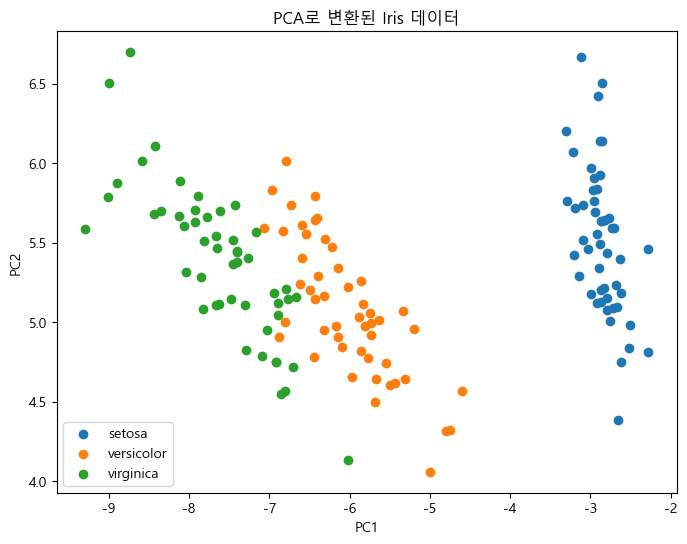

In [ ]:
# Iris 데이터 셋을 불러옵니다.
iris = load_iris()
# 데이터와 타겟을 확인합니다.
X_iris = iris.data
y_iris = iris.target
# 데이터와 타겟의 의미는, X_iris는 꽃받침 길이, 꽃받침 너비, 꽃잎 길이, 꽃잎 너비의 4가지 특징을 나타내며, y_iris는 각각의 샘플이 어떤 품종에 속하는지를 나타냅니다.
# Iris 데이터 셋은 150개의 샘플로 구성되어 있으며, 각 샘플은 4개의 특징과 1개의 타겟으로 이루어져 있습니다. 타겟은 0, 1, 2로 표현되며, 각각 setosa, versicolor, virginica 품종을 나타냅니다.

# 데이터와 타겟의 형태를 확인합니다.
print("데이터 형태:", X_iris.shape)
print("타겟 형태:", y_iris.shape)
# 데이터의 첫 5개 샘플을 확인합니다.
print("데이터 샘플:\n", X_iris[:5])
print("타겟 샘플:\n", y_iris[:5])
print("----------------------------------------------------------------------------------")


# PCA 를 수행하기 전, 데이터의 형태를 확인합니다.
print("PCA 적용 전 데이터 형태:", X_iris.shape)
# 데이터의 특징 수는 4개입니다. PCA를 적용하여 2개의 주성분으로 변환할 예정입니다.
# 먼저 4개의 특징이 무엇인지 확인합니다.
print("특징 이름:", iris.feature_names)
print("----------------------------------------------------------------------------------")

# 공분산 행렬을 계산합니다. PCA는 공분산 행렬의 고유값과 고유벡터를 이용하여 데이터를 변환합니다.
cov_matrix = np.cov(X_iris, rowvar=False) #rowvar=False는 각 열이 하나의 변수임을 나타냅니다
# 공분산 행렬의 형태를 확인합니다.
print("공분산 행렬 형태:", cov_matrix.shape)
print("----------------------------------------------------------------------------------")


# 3. 고유값과 고유벡터를 계산합니다.
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# 고유값을 내림차순으로 정렬합니다.
sorted_indices = np.argsort(eigenvalues)[::-1]
# 내림차순으로 정렬한 고유값과 고유벡터를 출력합니다
print("고유값 (내림차순):", eigenvalues[sorted_indices])
print("고유벡터 (내림차순):\n", eigenvectors[:, sorted_indices])
print("----------------------------------------------------------------------------------")

# 4. PC score를 계산합니다.
PC_scores = np.dot(X_iris, eigenvectors[:, sorted_indices])
# PC score의 형태를 확인합니다.
print("PC score 형태:", PC_scores.shape)
# k=2로 설정하여, 2개의 주성분을 선택합니다.
k = 2
# 선택한 주성분으로 데이터를 변환합니다.
X_pca = PC_scores[:, :k]



# 선택된 주성분이 iris 데이터의 특징 중에 어떤 특징을 나타내는지 확인합니다.
# PCA로 변환된 데이터는 원래의 4차원 공간에서 2차원으로 투영된 것이므로, 선택된 주성분이 원본의 특징과 직접적으로 대응되지 않습니다.
# 따라서 선택된 주성분이 나타내는 특징을 원본의 특징과 직접적으로 연결하기는 어렵습니다.
# 하지만, PCA로 변환된 데이터에서 선택된 주성분이 원본의 특징과 어떤 관계가 있는지 이해하기 위해서는, 고유벡터의 구성 요소를 분석해야 합니다. 
explained_variance_ratio = eigenvalues[sorted_indices] / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)
for i, (ev, cv) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"PC{i+1}: {ev*100:.1f}%  누적: {cv*100:.1f}%")
# 위의 출력에서 PC1과 PC2가 각각 전체 분산의 약 72.9%와 23.0%를 설명하며, 누적 분산은 약 95.9%입니다.
print("----------------------------------------------------------------------------------")


# PCA로 변환된 데이터를 시각화하기 위해 필요한 라이브러리를 불러옵니다.
import matplotlib.pyplot as plt
# PCA로 변환된 데이터를 시각화합니다.2개의 주성분을 x축과 y축으로 사용하여, 각 클래스별로 색상을 다르게 표시합니다.
# 각 클래스는 iris.target_names에 정의된 이름으로 레이블을 붙입니다.
plt.figure(figsize=(8, 6))
for target in np.unique(y_iris):
    plt.scatter(X_pca[y_iris == target, 0], X_pca[y_iris == target, 1], label=iris.target_names[target])    
# 그래프에 제목과 축 레이블을 추가합니다. 
# PCA로 변환된 데이터는 원래의 4차원 공간에서 2차원으로 투영된 것이므로, x축과 y축은 각각 첫 번째와 두 번째 주성분을 나타냅니다. 
# 원본의 특징이 아닙니다. 따라서 축 레이블은 PC1과 PC2로 표시합니다.
plt.title("PCA로 변환된 Iris 데이터")
plt.xlabel("PC1")
plt.ylabel("PC2")
# 범례를 추가합니다.
plt.legend()
# 그래프를 표시합니다.
plt.show()


# 디지트 데이터 PCA 실습


from sklearn.datasets import load_digits

In [49]:
from sklearn.datasets import load_digits

PCA 적용 전 데이터 형태: (1797, 64)
특징 이름: ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']
----------------------------------------------------------------------------------
공분산 행렬 형태: (64, 64)
-----------------------------

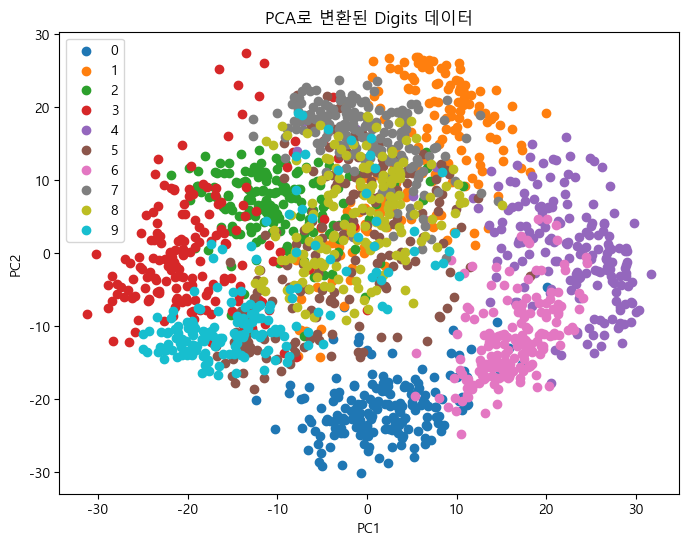

In [51]:
# Digits 데이터 셋을 불러옵니다.
digits = load_digits()
# 데이터와 타겟을 확인합니다. 데이터와 타겟은 각각 1797개의 샘플로 구성되어 있으며, 
# 각 샘플은 64개의 특징과 1개의 타겟으로 이루어져 있습니다. 타겟은 0부터 9까지의 숫자를 나타냅니다.
# 타겟의 의미는 각 샘플이 어떤 숫자에 해당하는지를 나타냅니다. 예를 들어, 타겟이 0인 샘플은 숫자 0을 나타내며, 타겟이 1인 샘플은 숫자 1을 나타냅니다.
# PCA를 적용하기 위해 필요한 라이브러리를 불러옵니다.
from sklearn.decomposition import PCA

# PCA를 적용하기 전, 데이터의 형태를 확인합니다.
print("PCA 적용 전 데이터 형태:", digits.data.shape)
# 데이터의 특징 수는 64개입니다. PCA를 적용하여 누적 분산 90%를 설명하는 주성분으로 변환할 예정입니다.
# 먼저 64개의 특징이 무엇인지 확인합니다.
print("특징 이름:", digits.feature_names)
print("----------------------------------------------------------------------------------")

# 공분산 행렬을 계산합니다. PCA는 공분산 행렬의 고유값과 고유벡터를 이용하여 데이터를 변환합니다.
cov_matrix = np.cov(digits.data, rowvar=False) #rowvar=False는 각 열이 하나의 변수임을 나타냅니다
# 공분산 행렬의 형태를 확인합니다.
print("공분산 행렬 형태:", cov_matrix.shape)
print("----------------------------------------------------------------------------------")

# 고유값과 고유벡터를 계산합니다. eigh 함수는 대칭 행렬의 고유값과 고유벡터를 계산하는 함수입니다. 
# 공분산 행렬은 대칭 행렬이므로, eigh 함수를 사용하여 고유값과 고유벡터를 계산할 수 있습니다.
# eig 와 eigh 함수의 차이점은, eig 함수는 일반 행렬의 고유값과 고유벡터를 계산하는 반면,
# eigh 함수는 대칭 행렬의 고유값과 고유벡터를 계산합니다.
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# 고유값을 내림차순으로 정렬합니다.
sorted_indices = np.argsort(eigenvalues)[::-1]


# PC score를 계산합니다.
PC_scores = np.dot(digits.data - np.mean(digits.data, axis=0), eigenvectors[:, sorted_indices])
# PC score의 형태를 확인합니다.
print("PC score 형태:", PC_scores.shape)
print("----------------------------------------------------------------------------------")


# 누적 분산이 90% 이상이 되는 주성분의 개수를 찾습니다.
explained_variance_ratio = eigenvalues[sorted_indices] / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)
k = np.argmax(cumulative_variance >= 0.90) + 1
print(f"누적 분산이 90% 이상이 되는 주성분의 개수: {k}") 


# 누적분산 90% 이상이 되는 주성분의 개수는 21개입니다. 따라서 PCA로 변환된 데이터에서 21개의 주성분을 선택하여, 
# 원본의 특징을 최대한 보존하면서 차원을 축소할 수 있습니다.
print(f"선택된 주성분의 개수: {k}")
print("----------------------------------------------------------------------------------")


# 누적 분산 90% 이상이 되는 주성분은 21개이지만, 시각화를 위해 2개의 주성분만 선택하겠습니다.
k = 2
print(f"선택된 주성분의 개수: {k}")
print("----------------------------------------------------------------------------------")
# 선택한 주성분으로 데이터를 변환합니다.
X_pca = PC_scores[:, :k]

# PC score의 형태를 확인합니다. 
# PCA로 변환된 데이터는 원래의 64차원 공간에서 2차원으로 투영된 것이므로, PC score의 형태는 (1797, 2)가 됩니다.
print("PCA로 변환된 데이터 형태:", X_pca.shape)
print ("----------------------------------------------------------------------------------")


# PCA로 변환된 데이터를 시각화하기 위해 필요한 라이브러리를 불러옵니다.
import matplotlib.pyplot as plt
# PCA로 변환된 데이터를 시각화합니다.2개의 주성분을 x축과 y축으로 사용하여, 각 클래스별로 색상을 다르게 표시합니다.
# 각 클래스는 digits.target_names에 정의된 이름으로 레이블을 붙입니다.
plt.figure(figsize=(8, 6))
for target in np.unique(digits.target):
    plt.scatter(X_pca[digits.target == target, 0], X_pca[digits.target == target, 1], label=digits.target_names[target])
# 그래프에 제목과 축 레이블을 추가합니다.
# PCA로 변환된 데이터는 원래의 64차원 공간에서 2차원으로 투영된 것이므로, x축과 y축은 각각 첫 번째와 두 번째 주성분을 나타냅니다.
# 원본의 특징이 아닙니다. 따라서 축 레이블은 PC1과 PC2로 표시합니다.
plt.title("PCA로 변환된 Digits 데이터")
plt.xlabel("PC1")
plt.ylabel("PC2")
# 범례를 추가합니다.
plt.legend()
# 그래프를 표시합니다.
plt.show()
